In [1]:
!cp -r /content/drive/MyDrive/photodata /content/

In [2]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os
from google.colab import drive
from pathlib import Path

In [3]:
drive.mount('/content/drive')
path = "/content/drive/MyDrive/photodata/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
size = 64
epochs = 100

In [5]:


IMAGE_SIZE = (size, size)
BATCH_SIZE = 32

# ---- How many images per class ----
SAMPLES = {
    "normal":       3800,
    "pneumonia":    4200,
    "tuberculosis": 2000
}

def load_balanced_data(folder_path, samples_per_class=None, shuffle=True):
    """
    Loads a balanced dataset by sampling a fixed number of images per class.
    samples_per_class: dict like {"normal": 4000, "pneumonia": 4000, "tuberculosis": 2000}
                       if None, loads all images (used for val/test)
    """
    folder = Path(folder_path)
    all_images = []
    all_labels = []
    class_names = ["normal", "pneumonia", "tuberculosis"]

    for label_index, class_name in enumerate(class_names):
        class_folder = folder / class_name
        image_paths = list(class_folder.glob("*.jpg")) + list(class_folder.glob("*.jpeg"))

        # Sample down if a limit is given, otherwise use all
        if samples_per_class and class_name in samples_per_class:
            limit = samples_per_class[class_name]
            if len(image_paths) < limit:
                print(f"⚠️  Warning: {class_name} only has {len(image_paths)} images, requested {limit}")
            image_paths = image_paths[:limit]

        all_images.extend([str(p) for p in image_paths])
        all_labels.extend([label_index] * len(image_paths))
        print(f"  {class_name}: {len(image_paths)} images (label={label_index})")

    print(f"  TOTAL: {len(all_images)} images\n")

    # Shuffle together so classes aren't all in a block
    if shuffle:
        combined = list(zip(all_images, all_labels))
        np.random.seed(42)
        np.random.shuffle(combined)
        all_images, all_labels = zip(*combined)

    # Build a tf.data pipeline from the file paths
    def load_and_preprocess(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_jpeg(image, channels=3)
        image = tf.image.resize(image, IMAGE_SIZE)
        image = tf.cast(image, tf.float32) / 255.0  # normalize to 0-1
        return image, label

    dataset = tf.data.Dataset.from_tensor_slices((list(all_images), list(all_labels)))

    dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.cache()
    dataset = dataset.shuffle(1000)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset, class_names


print("Loading train data...")
train_data, class_names = load_balanced_data(
    "/content/photodata/train",
    samples_per_class=SAMPLES
)

# Val and test use all available images (no sampling needed)
print("Loading val data...")
val_data, _ = load_balanced_data(
    "/content/photodata/val",
    samples_per_class=None
)

print("Loading test data...")
test_data, _ = load_balanced_data(
    "/content/photodata/test",
    samples_per_class=None
)

print("Classes:", class_names)

Loading train data...
  normal: 3800 images (label=0)
  pneumonia: 4200 images (label=1)
  tuberculosis: 2000 images (label=2)
  TOTAL: 10000 images

Loading val data...
  normal: 900 images (label=0)
  pneumonia: 570 images (label=1)
  tuberculosis: 1064 images (label=2)
  TOTAL: 2534 images

Loading test data...
  normal: 925 images (label=0)
  pneumonia: 580 images (label=1)
  tuberculosis: 1064 images (label=2)
  TOTAL: 2569 images

Classes: ['normal', 'pneumonia', 'tuberculosis']


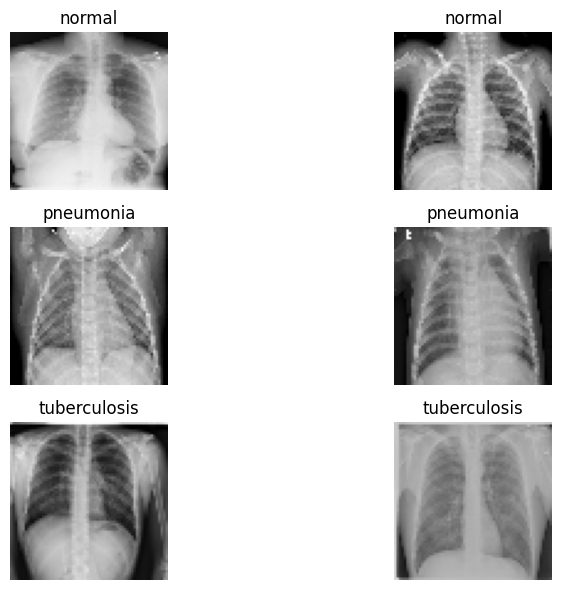

In [6]:
def show_sample_images(dataset, class_names, num_per_class=2):
    # Collect images per class
    class_images = {i: [] for i in range(len(class_names))}

    for images, labels in dataset:
        for i in range(len(images)):
            label_index = int(labels[i].numpy())
            if len(class_images[label_index]) < num_per_class:
                class_images[label_index].append(images[i].numpy())
        # Stop once we have enough for every class
        if all(len(v) >= num_per_class for v in class_images.values()):
            break

    total = len(class_names) * num_per_class
    plt.figure(figsize=(5 * num_per_class, 4 * len(class_names) // 2))
    plot_index = 1
    for label_index, imgs in class_images.items():
        for img in imgs:
            plt.subplot(len(class_names), num_per_class, plot_index)
            plt.imshow(img)
            plt.title(class_names[label_index])
            plt.axis("off")
            plot_index += 1

    plt.tight_layout()
    plt.show()

show_sample_images(train_data, class_names)

In [7]:
def build_model():
    model = keras.Sequential([
        # --- Feature detection ---
        keras.layers.Conv2D(16, (3, 3), activation="relu", input_shape=(size, size, 3)),
        keras.layers.MaxPooling2D(),

        keras.layers.Conv2D(32, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D(),

        # --- Decision making ---
        keras.layers.Flatten(),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(3, activation="softmax")  # 3 classes: normal, pneumonia, tuberculosis
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",  # use this for integer labels (0, 1, 2)
        metrics=["accuracy"]
    )

    return model

model = build_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 406,755 (1.55 MB)

 Trainable params: 406,755 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:

# Upweight pneumonia (label=1) so missing it is penalized harder
class_weights = {
    0: 1.0,  # normal
    1: 1.5,  # pneumonia — penalize misses more
    2: 0.8   # tuberculosis — slightly less important
}

MODEL_PATH = "pneumoniaClassifierw/tuberculosis.keras"

if os.path.exists(MODEL_PATH):
    print("Loading saved model...")
    model = keras.models.load_model(MODEL_PATH)
    history = None
else:
    print("No saved model found. Training from scratch...")
    model = build_model()
    history = model.fit(
        train_data,
        epochs=epochs,
        validation_data=val_data,  # use val_data here, not test_data
        class_weight=class_weights
    )
    model.save(MODEL_PATH)
    print("Model saved!")

No saved model found. Training from scratch...
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.6795 - loss: 0.7840 - val_accuracy: 0.7076 - val_loss: 0.6902
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7973 - loss: 0.5062 - val_accuracy: 0.7028 - val_loss: 0.6513
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8098 - loss: 0.4475 - val_accuracy: 0.6926 - val_loss: 0.7281
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8244 - loss: 0.4203 - val_accuracy: 0.7332 - val_loss: 0.5699
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8272 - loss: 0.4051 - val_accuracy: 0.7261 - val_loss: 0.6547
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8310 - loss: 0.3877 - val_accuracy: 0.7273 - val_loss: 0.6118
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8361 - loss: 0.3764 - val_accuracy: 0.7265 - val_loss: 0.5544
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8401 - loss: 0.3662 - val_accuracy: 0.713

In [15]:
all_labels = []
predicted_labels = []

for images, labels in test_data:
    preds = model.predict(images, verbose=0)
    predicted_labels.extend(np.argmax(preds, axis=1))  # pick the highest probability class
    all_labels.extend(labels.numpy().astype(int))

print(f"Labels: {len(all_labels)}, Predictions: {len(predicted_labels)}")  # should match

Labels: 2569, Predictions: 2569


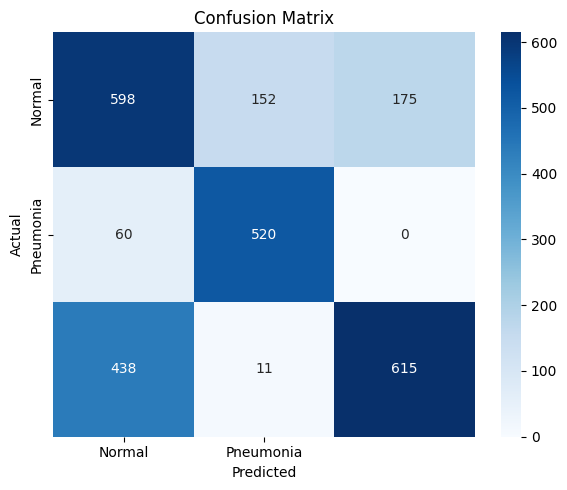

In [16]:
cm = confusion_matrix(all_labels, predicted_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np
class_names = ["normal", "pneumonia", "tuberculosis"]
# --- Collect predictions ---
all_labels = []
predicted_labels = []
all_probs = []

for images, labels in test_data:
    preds = model.predict(images, verbose=0)
    all_probs.extend(preds)
    predicted_labels.extend(np.argmax(preds, axis=1))
    all_labels.extend(labels.numpy().astype(int))

all_labels       = np.array(all_labels)
predicted_labels = np.array(predicted_labels)
all_probs        = np.array(all_probs)

# --- Per-class report (accuracy, precision, recall, f1) ---
print("=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(all_labels, predicted_labels, target_names=class_names))

# --- Overall accuracy ---
overall_acc = np.mean(all_labels == predicted_labels)
print(f"Overall Accuracy: {overall_acc:.2%}")

# --- Per-class accuracy ---
print("\nPer-Class Accuracy:")
for i, name in enumerate(class_names):
    mask = all_labels == i
    class_acc = np.mean(predicted_labels[mask] == i)
    print(f"  {name}: {class_acc:.2%}")

# --- AUC-ROC (one-vs-rest for multiclass) ---
all_labels_bin = label_binarize(all_labels, classes=[0, 1, 2])
auc_scores = roc_auc_score(all_labels_bin, all_probs, average=None)
print("\nAUC-ROC Per Class:")
for name, score in zip(class_names, auc_scores):
    print(f"  {name}: {score:.4f}")
print(f"  Macro Average: {np.mean(auc_scores):.4f}")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      normal       0.55      0.65      0.59       925
   pneumonia       0.76      0.90      0.82       580
tuberculosis       0.78      0.58      0.66      1064

    accuracy                           0.67      2569
   macro avg       0.70      0.71      0.69      2569
weighted avg       0.69      0.67      0.67      2569

Overall Accuracy: 67.46%

Per-Class Accuracy:
  normal: 64.65%
  pneumonia: 89.66%
  tuberculosis: 57.80%

AUC-ROC Per Class:
  normal: 0.7614
  pneumonia: 0.9757
  tuberculosis: 0.8509
  Macro Average: 0.8626


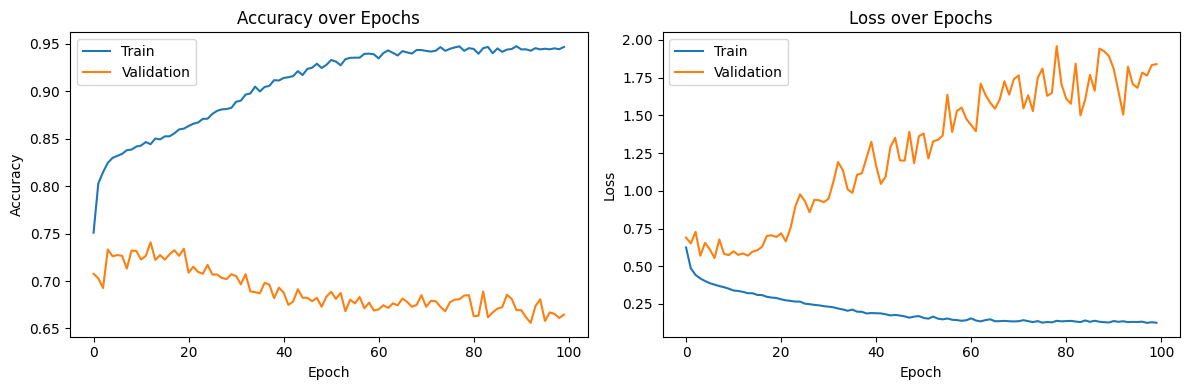

In [18]:
if history is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history["accuracy"],     label="Train")
    ax1.plot(history.history["val_accuracy"], label="Validation")
    ax1.set_title("Accuracy over Epochs")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()

    ax2.plot(history.history["loss"],     label="Train")
    ax2.plot(history.history["val_loss"], label="Validation")
    ax2.set_title("Loss over Epochs")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()

    plt.tight_layout()
    plt.show()
else:
    print("No training history available (model was loaded from file).")